# **4.5 Weight Decay**
**We can always mitigate overfitting by collecting more training data. However, this can be costly, time-consuming, or completely beyond our control, making it impractical in the short term.** Assuming we already have as much high-quality data as possible, we can then focus on regularization techniques.<br><br>
Recall that in the example of polynomial regression [(Section 4.4)](model_selection_under_over_fit.ipynb#44), we can limit the model’s capacity by adjusting the degree of the fitting polynomial. In fact, **limiting the number of features is a common technique for mitigating overfitting.** However, simply discarding features may be too crude an approach for this task. Let’s continue with the example of polynomial regression and consider what might happen with high-dimensional inputs. The natural extension of polynomials to multivariate data is called monomials—essentially, the product of powers of the variables. **The degree of a monomial is the sum of the powers.** For example, $x^{2}_{1}x_{2}$ and $x_{3}x_{5}^{2}$ are both cubic monomials.<br><br>
Note that as the order $d$ increases, the number of terms of order $d$ increases rapidly. Given $k$ variables, the number of terms of order $d$ is
$
\begin{pmatrix}
k-1+d \\
k-1
\end{pmatrix}
$
, that is, $C_{k−1+d}^{k−1} = \frac{(k-1+d)!}{(d)!(k−1)!}$. Therefore, even a slight change in order—such as from 2 to 3—will significantly increase the complexity of our model. Simply
limiting the number of features—which, in polynomial regression, is reflected in limiting the degree—may still leave the model oscillating between being too simple and too complex. We need a more granular tool to adjust the function’s complexity so that it reaches an appropriate balance.

### **Norm and Weighted Decay**
**When training parametric machine learning models, weight decay is one of the most widely used regularization techniques; it is also commonly referred to as $L_2$ regularization.** This technique measures the complexity of a function by its distance from zero, since, among all functions $f$, the function $f$ = 0 (where all inputs yield the value 0) is, in a sense, the simplest. But how exactly should we measure the distance between a function and zero? There is no single correct answer. In fact, research in functional analysis and the theory of Banach spaces is dedicated to answering this question.<br><br>
A simple method is to measure the complexity of a weight vector in a linear function $f(x) = w^{T}x$ using a certain norm of the weight vector, such as $||w||^{2}$. **To ensure that the weight vector remains relatively small, the most common approach is to add its norm as a penalty term to the problem of minimizing the loss. The original training objective—minimizing the prediction loss on the training labels—is adjusted to minimize the sum of the prediction loss and the penalty term.** Now, if our weight vector grows too large, our
learning algorithm may focus more on minimizing the weight norm $∥w∥^{2}$. Our loss is given by the following equation:
##### **(4.5.1)**
$$L(w,b) = \frac{1}{n}\sum\limits_{i=1}^{n}\frac{1}{2}\left(w^{T}x^{(i)}+b-y^{(i)}\right)^{2}$$
To recap, $x^{(i)}$ is the feature of sample $i$, $y^{(i)}$ is the label of sample $i$, and $(w, b)$ are the weight and bias parameters. To penalize the magnitude of the weight vector, we must somehow incorporate ∥w∥² into the loss function, but how should the model balance this new, additional penalty against the loss? In practice, we describe this trade-off through the regularization constant $\lambda$, a non-negative hyperparameter that we fit using validation data:
##### **(4.5.2)**
$$L(w,b)+\frac{\lambda}{2}||w||^{2}$$
For $\lambda = 0$, we revert to the original loss function. For $\lambda > 0$, we constrain the magnitude of ∥w∥. Here, we still divide by 2: when we take the derivative of a quadratic function, 2 and 1/2 cancel each other out, ensuring that the update expression looks both elegant and simple. Why do we use the squared norm here instead of the standard norm (i.e., Euclidean distance)? **We do this for computational convenience. By squaring the $L_2$ norm, we eliminate the square root, leaving the sum of the squares of each component of the weight vector. This makes it easy to compute the derivative of the penalty: the sum of the derivatives equals the derivative of the sum.**<br><br>
Furthermore, why do we use the $L_2$ norm rather than the $L_1$ norm in the first place? **In fact, this choice is valid and widely accepted throughout the field of statistics. $L_2$-regularized linear models form the basis of the classic ridge regression algorithm, while $L_1$-regularized linear regression is a similar fundamental model in statistics, commonly referred to as lasso regression. One reason for using the $L_2$ norm is that it imposes a heavy penalty on large components of the weight vector. This causes our learning algorithms to favor models that distribute weights evenly across a large number of features. In practice, this may make them more robust to observation errors in individual variables. In contrast, $L_1$ regularization causes the model to concentrate weights on a small subset of features while setting the weights of the others to zero. This is known as feature selection**, which may be desirable in other scenarios.<br><br>
The mini-batch stochastic gradient descent update for L2-regularized regression is given by the following equation:
##### **(4.5.3)**
$$w \leftarrow (1-\eta\lambda)w-\frac{\eta}{|\mathcal{B}|}\sum\limits_{i \in \mathcal{B}}x^{(i)}\left(w^{T}x^{(i)}+b-y^{(i)}\right)$$
As discussed in previous sections, we update $w$ based on the difference between the estimated values and the observed values. However, we are also attempting to reduce the magnitude of $w$ to zero. This is why this method is sometimes referred to as weight decay. By focusing solely on the penalty term, the optimization algorithm decays the weights at each step of training. Compared to feature selection, weight decay provides us with a continuous mechanism for adjusting the complexity of the function. Smaller values of $\lambda$ correspond to less constraint on $w$, while larger values of $\lambda$ impose greater constraints on $w$.<br><br>
Whether to penalize the corresponding bias $b^2$ varies depending on the specific implementation and may also differ across different layers of a neural network. **Typically, the bias terms in the network’s output layer are not regularized.**

## **4.5.1 High-Dimensional Linear Regression**
Let's use a simple example to demonstrate weight decay.

In [1]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

First, let’s generate some data as we did before. The formula is as follows:
##### **(4.5.4)**
$$y=0.05+\sum\limits_{i=1}^{d}0.01x_{i}+\epsilon \quad where \quad \epsilon \sim \mathcal{N}(0, 0.01^{2})$$
We choose labels that are linear functions of the input. The labels are also corrupted by Gaussian noise with a mean of 0 and a standard deviation of 0.01. To make the overfitting effect more pronounced, we can increase the dimensionality of the problem to $d$ = 200 and use a small training set containing only 20 samples.

In [2]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

## **4.5.2 Implementation from Scratch**
Next, we will implement weight decay from scratch by simply adding the $L_2$ squared penalty to the original objective function.

### **Initialize Model Parameters**
First, we will define a function to randomly initialize the model parameters.

In [3]:
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

### **Defining the $L_2$ Norm Penalty**
The easiest way to implement this penalty is to square all the terms and then sum them.

In [4]:
def l2_penalty(w):
    return torch.sum(torch.pow(w, 2)) / 2

### **Defining the Training Code Implementation**
The code below fits the model to the training dataset and evaluates it on the test dataset. The linear network and squared loss remain unchanged, so we import them using `d2l.linreg` and `d2l.squared_loss`. The only change is that the loss now includes a penalty term.

In [5]:
def train(lambda_value):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log', xlim=(5, num_epochs), legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # An L2 norm penalty term has been added
            # the broadcast mechanism transforms l2_penalty(w) into a vector of length batch_size.
            l = loss(net(X), y) + lambda_value * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss), d2l.evaluate_loss(net, test_iter, loss)))
    print('The L2 norm of w is: ', torch.norm(w).item())

### **Train without regularization**
Let's now run this code with `lambda_value = 0` to disable weight decay. Note that while the training error has decreased, the test error has not; this indicates severe overfitting.

The L2 norm of w is:  13.848199844360352


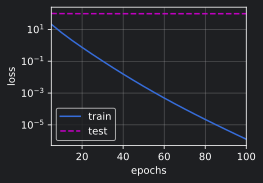

In [6]:
train(lambda_value=0)

### **Using Weight Decay**
Next, we'll run the code using weight decay. Note that here, the training error increases, but the test error decreases. This is exactly the effect we expect to achieve through regularization.

The L2 norm of w is:  0.3760737180709839


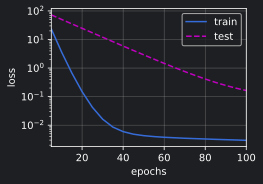

In [7]:
train(lambda_value=3)

## **4.5.3 A Simple Implementation**
Since weight decay is commonly used in neural network optimization, deep learning frameworks integrate it into optimization algorithms to make it easier for us to use, allowing it to be combined with any loss function. Furthermore, this integration offers computational benefits, allowing weight decay to be incorporated into the algorithm without incurring any additional computational overhead. **Since the weight decay component of the update depends solely on the current value of each parameter, the optimizer must access each parameter at least once**.<br><br>
In the code below, we specify the `weight_decay` hyperparameter directly via `weight_decay` when instantiating the optimizer. **By default, PyTorch decays both weights and biases**. Here, we have set `weight_decay` only for the weights, so the bias parameter `b` will not decay.

In [8]:
def train_concise(weight_decay_value):
    net = nn.Sequential(nn.Linear(num_inputs,1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    # The offset parameters have not decayed
    trainer = torch.optim.SGD([
        {"params": net[0].weight, "weight_decay": weight_decay_value},
        {"params": net[0].bias},
    ], lr=lr)
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log', xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss), d2l.evaluate_loss(net, test_iter, loss)))
    print('The L2 norm of w is: ', net[0].weight.norm().item())

These graphs look the same as those we obtained when implementing weight decay from scratch. However, they run faster and are easier to implement. For more complex problems, this advantage will become even more apparent.

The L2 norm of w is:  14.328399658203125


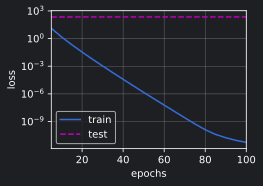

In [9]:
train_concise(0)

The L2 norm of w is:  0.3563503324985504


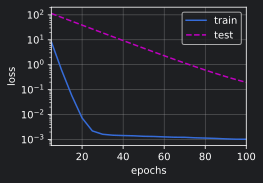

In [10]:
train_concise(3)

**In this book, we will use a simple heuristic by default, which involves applying weight decay to all layers of deep neural networks**.

## **Summary**
  * Regularization is a common method for addressing overfitting: a penalty term is added to the loss function of the training set to reduce the complexity of the learned model.
  * One specific way to keep the model simple is to use weight decay with $L_2$ regularization. This results in weight decay during the learning algorithm's update steps.
  * The weight decay feature is provided by the optimizer in deep learning frameworks.
  * Within the same training code implementation, different sets of parameters can exhibit different update behaviors.
